Imports and project paths

In [22]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio

from rasterio.enums import Resampling
from rasterio.warp import reproject
from shapely.geometry import box

In [2]:
current_directory = Path.cwd()

if (current_directory / "data").exists():
    project_root = current_directory
else:
    project_root = current_directory.parent

red_2025_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2025-08-02"
    / "B04_2025-08-02.tif"
)

print("Project root:", project_root)
print("2025 raster exists:", red_2025_path.exists())

Project root: /Users/eleazar/Documents/wetland-change-manitoba
2025 raster exists: True


Create the study-area GeoJSON

In [3]:
reference_directory = project_root / "data" / "reference"
reference_directory.mkdir(parents=True, exist_ok=True)

aoi_output_path = reference_directory / "oak_hammock_study_area.geojson"

with rasterio.open(red_2025_path) as src:
    raster_bounds = src.bounds
    raster_crs = src.crs

study_area = gpd.GeoDataFrame(
    {
        "name": ["Oak Hammock Marsh study area"],
        "source": ["Sentinel-2 export extent"],
        "reference_date": ["2025-08-02"],
    },
    geometry=[box(*raster_bounds)],
    crs=raster_crs,
)

# Copernicus accepts geographic coordinates conveniently in WGS 84.
study_area_wgs84 = study_area.to_crs("EPSG:4326")

study_area_wgs84.to_file(
    aoi_output_path,
    driver="GeoJSON",
)

print("AOI saved to:")
print(aoi_output_path)

study_area_wgs84

AOI saved to:
/Users/eleazar/Documents/wetland-change-manitoba/data/reference/oak_hammock_study_area.geojson


,name,source,reference_date,geometry
0,Oak Hammock Marsh study area,Sentinel-2 export extent,2025-08-02,"POLYGON ((-96.88606 50.18233, -96.87793 50.365..."


Preview the study area

Text(36.472222222222214, 0.5, 'Latitude')

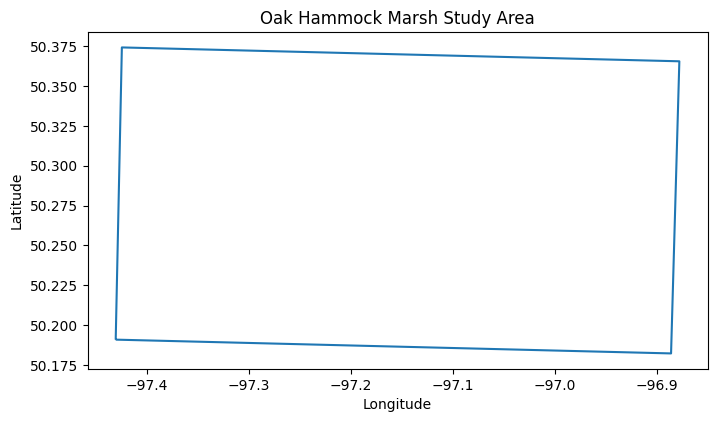

In [4]:
ax = study_area_wgs84.boundary.plot(figsize=(8, 6))

ax.set_title("Oak Hammock Marsh Study Area")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

Define all Sentinel-2 band paths

In [5]:
import numpy as np

red_2020_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2020-08-08"
    / "B04_2020-08-08.tif"
)

nir_2020_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2020-08-08"
    / "B08_2020-08-08.tif"
)

nir_2025_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2025-08-02"
    / "B08_2025-08-02.tif"
)

paths = {
    "2020 B04": red_2020_path,
    "2020 B08": nir_2020_path,
    "2025 B04": red_2025_path,
    "2025 B08": nir_2025_path,
}

for name, path in paths.items():
    print(f"{name}: {path.exists()} — {path}")

2020 B04: True — /Users/eleazar/Documents/wetland-change-manitoba/data/raw/sentinel2/2020-08-08/B04_2020-08-08.tif
2020 B08: True — /Users/eleazar/Documents/wetland-change-manitoba/data/raw/sentinel2/2020-08-08/B08_2020-08-08.tif
2025 B04: True — /Users/eleazar/Documents/wetland-change-manitoba/data/raw/sentinel2/2025-08-02/B04_2025-08-02.tif
2025 B08: True — /Users/eleazar/Documents/wetland-change-manitoba/data/raw/sentinel2/2025-08-02/B08_2025-08-02.tif


Raster metadata function

In [6]:
def get_raster_metadata(path):
    """Read the spatial and technical properties of a raster."""

    with rasterio.open(path) as src:
        return {
            "crs": src.crs,
            "width": src.width,
            "height": src.height,
            "shape": (src.height, src.width),
            "transform": src.transform,
            "bounds": src.bounds,
            "resolution": src.res,
            "dtype": src.dtypes[0],
            "nodata": src.nodata,
        }

Inspect the four rasters

In [7]:
metadata = {
    name: get_raster_metadata(path)
    for name, path in paths.items()
}

for name, info in metadata.items():
    print(f"\n{name}")
    print("-" * len(name))

    for key, value in info.items():
        print(f"{key}: {value}")


2020 B04
--------
crs: EPSG:32614
width: 2500
height: 1357
shape: (1357, 2500)
transform: | 15.79, 0.00, 612026.01|
| 0.00,-16.44, 5582386.34|
| 0.00, 0.00, 1.00|
bounds: BoundingBox(left=612026.012689, bottom=5560081.552097, right=651500.116106, top=5582386.338637)
resolution: (15.789641366800014, 16.436836064848762)
dtype: uint16
nodata: None

2020 B08
--------
crs: EPSG:32614
width: 2500
height: 1357
shape: (1357, 2500)
transform: | 15.79, 0.00, 612026.01|
| 0.00,-16.44, 5582386.34|
| 0.00, 0.00, 1.00|
bounds: BoundingBox(left=612026.012689, bottom=5560081.552097, right=651500.116106, top=5582386.338637)
resolution: (15.789641366800014, 16.436836064848762)
dtype: uint16
nodata: None

2025 B04
--------
crs: EPSG:32614
width: 2500
height: 1253
shape: (1253, 2500)
transform: | 15.57, 0.00, 612005.80|
| 0.00,-16.26, 5581419.63|
| 0.00, 0.00, 1.00|
bounds: BoundingBox(left=612005.802059, bottom=5561042.057073, right=650919.85416, top=5581419.634547)
resolution: (15.565620840399992, 16.2

Function to compare raster grids

In [8]:
def compare_raster_grids(path_a, path_b):
    """Compare whether two rasters use the same spatial grid."""

    with rasterio.open(path_a) as raster_a, rasterio.open(path_b) as raster_b:
        return {
            "same_crs": raster_a.crs == raster_b.crs,
            "same_dimensions": (
                raster_a.width == raster_b.width
                and raster_a.height == raster_b.height
            ),
            "same_resolution": np.allclose(
                raster_a.res,
                raster_b.res,
            ),
            "same_transform": np.allclose(
                tuple(raster_a.transform),
                tuple(raster_b.transform),
            ),
            "same_bounds": np.allclose(
                tuple(raster_a.bounds),
                tuple(raster_b.bounds),
            ),
        }

Check alignment within each year

In [9]:
alignment_2020 = compare_raster_grids(
    red_2020_path,
    nir_2020_path,
)

alignment_2025 = compare_raster_grids(
    red_2025_path,
    nir_2025_path,
)

print("2020 B04 and B08 alignment")
for test, result in alignment_2020.items():
    print(f"{test}: {result}")

print("\n2025 B04 and B08 alignment")
for test, result in alignment_2025.items():
    print(f"{test}: {result}")

2020 B04 and B08 alignment
same_crs: True
same_dimensions: True
same_resolution: True
same_transform: True
same_bounds: True

2025 B04 and B08 alignment
same_crs: True
same_dimensions: True
same_resolution: True
same_transform: True
same_bounds: True


Compare the 2020 and 2025 grids

In [10]:
alignment_between_dates = compare_raster_grids(
    red_2020_path,
    red_2025_path,
)

print("2020 and 2025 grid comparison")

for test, result in alignment_between_dates.items():
    print(f"{test}: {result}")

2020 and 2025 grid comparison
same_crs: True
same_dimensions: False
same_resolution: False
same_transform: False
same_bounds: False


Import the alignment tools

In [11]:
from rasterio.enums import Resampling
from rasterio.warp import reproject

Create an alignment function

In [12]:
ALIGNMENT_NODATA = -9999.0


def align_to_reference(source_path, reference_path):
    """
    Resample a source raster onto the exact grid of a reference raster.

    The output inherits the reference raster's:
    - CRS
    - dimensions
    - transform
    - resolution
    - geographic extent
    """

    with rasterio.open(reference_path) as reference:
        destination = np.full(
            (reference.height, reference.width),
            ALIGNMENT_NODATA,
            dtype="float32",
        )

        reference_metadata = {
            "crs": reference.crs,
            "transform": reference.transform,
            "width": reference.width,
            "height": reference.height,
            "profile": reference.profile.copy(),
        }

    with rasterio.open(source_path) as source:
        source_array = source.read(
            1,
            masked=True,
        ).astype("float32")

        source_for_reprojection = source_array.filled(
            ALIGNMENT_NODATA
        )

        reproject(
            source=source_for_reprojection,
            destination=destination,
            src_transform=source.transform,
            src_crs=source.crs,
            src_nodata=ALIGNMENT_NODATA,
            dst_transform=reference_metadata["transform"],
            dst_crs=reference_metadata["crs"],
            dst_nodata=ALIGNMENT_NODATA,
            resampling=Resampling.bilinear,
        )

    aligned_array = np.ma.masked_equal(
        destination,
        ALIGNMENT_NODATA,
    )

    return aligned_array, reference_metadata

Align the 2020 bands to the 2025 grid

In [13]:
red_2020_aligned, reference_metadata = align_to_reference(
    red_2020_path,
    red_2025_path,
)

nir_2020_aligned, _ = align_to_reference(
    nir_2020_path,
    red_2025_path,
)

print("Aligned 2020 B04 shape:", red_2020_aligned.shape)
print("Aligned 2020 B08 shape:", nir_2020_aligned.shape)

print(
    "Aligned bands have the same shape:",
    red_2020_aligned.shape == nir_2020_aligned.shape,
)

Aligned 2020 B04 shape: (1253, 2500)
Aligned 2020 B08 shape: (1253, 2500)
Aligned bands have the same shape: True


Load the original 2025 bands

In [14]:
def read_masked_raster(path):
    """Read one raster band as a masked float32 array."""

    with rasterio.open(path) as source:
        return source.read(
            1,
            masked=True,
        ).astype("float32")


red_2025 = read_masked_raster(red_2025_path)
nir_2025 = read_masked_raster(nir_2025_path)

print("2025 B04 shape:", red_2025.shape)
print("2025 B08 shape:", nir_2025.shape)

print(
    "All four arrays now have the same shape:",
    red_2020_aligned.shape
    == nir_2020_aligned.shape
    == red_2025.shape
    == nir_2025.shape,
)

2025 B04 shape: (1253, 2500)
2025 B08 shape: (1253, 2500)
All four arrays now have the same shape: True


Calculate NDVI for both dates

In [15]:
def calculate_ndvi(red, nir):
    """Calculate NDVI while preserving invalid and NoData pixels."""

    red_values = red.filled(np.nan)
    nir_values = nir.filled(np.nan)

    denominator = nir_values + red_values

    with np.errstate(divide="ignore", invalid="ignore"):
        ndvi_values = (
            nir_values - red_values
        ) / denominator

    invalid_pixels = (
        np.ma.getmaskarray(red)
        | np.ma.getmaskarray(nir)
        | ~np.isfinite(ndvi_values)
        | (denominator == 0)
    )

    ndvi = np.ma.array(
        np.clip(ndvi_values, -1, 1),
        mask=invalid_pixels,
    )

    return ndvi


ndvi_2020 = calculate_ndvi(
    red_2020_aligned,
    nir_2020_aligned,
)

ndvi_2025 = calculate_ndvi(
    red_2025,
    nir_2025,
)

print("2020 NDVI shape:", ndvi_2020.shape)
print("2025 NDVI shape:", ndvi_2025.shape)

print()
print("2020 NDVI mean:", float(ndvi_2020.mean()))
print("2025 NDVI mean:", float(ndvi_2025.mean()))

2020 NDVI shape: (1253, 2500)
2025 NDVI shape: (1253, 2500)

2020 NDVI mean: 0.5867086659085022
2025 NDVI mean: 0.6009170746909736


Restrict both dates to their common valid area

In [16]:
valid_overlap = (
    ~np.ma.getmaskarray(ndvi_2020)
    & ~np.ma.getmaskarray(ndvi_2025)
)

ndvi_2020_common = np.ma.array(
    ndvi_2020,
    mask=~valid_overlap,
)

ndvi_2025_common = np.ma.array(
    ndvi_2025,
    mask=~valid_overlap,
)

valid_pixel_count = int(valid_overlap.sum())
total_pixel_count = valid_overlap.size

valid_percentage = (
    valid_pixel_count / total_pixel_count
) * 100

print("Valid overlapping pixels:", valid_pixel_count)
print(f"Valid overlap: {valid_percentage:.2f}%")

Valid overlapping pixels: 2563600
Valid overlap: 81.84%


This prevents areas missing from either acquisition from being interpreted as vegetation change.

Calculate NDVI change

The direction will be:

NDVI change = 2025 NDVI − 2020 NDVI

In [18]:
ndvi_change = ndvi_2025_common - ndvi_2020_common

print("Minimum NDVI change:", float(ndvi_change.min()))
print("Maximum NDVI change:", float(ndvi_change.max()))
print("Mean NDVI change:", float(ndvi_change.mean()))
print("Median NDVI change:", float(np.ma.median(ndvi_change)))

Minimum NDVI change: -1.855431318283081
Maximum NDVI change: 0.8903528451919556
Mean NDVI change: 0.0053318724005061244
Median NDVI change: 0.012064486742019653


Plot the change map

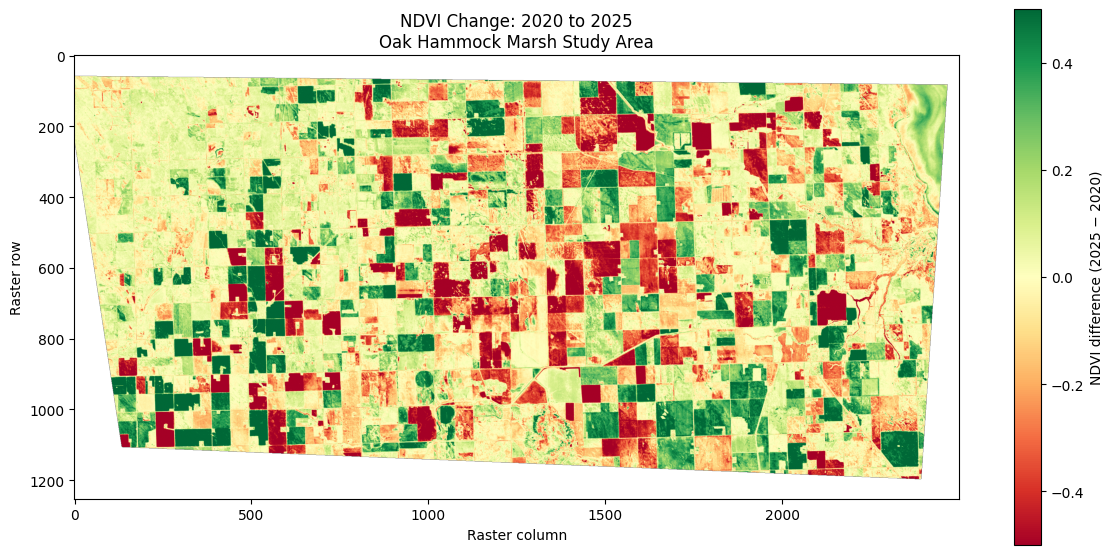

Figure saved to:
/Users/eleazar/Documents/wetland-change-manitoba/outputs/figures/ndvi_change_2020_2025.png


In [24]:
fig, ax = plt.subplots(figsize=(12, 7))

change_image = ax.imshow(
    ndvi_change,
    cmap="RdYlGn",
    vmin=-0.5,
    vmax=0.5,
)

ax.set_title(
    "NDVI Change: 2020 to 2025\n"
    "Oak Hammock Marsh Study Area"
)
ax.set_xlabel("Raster column")
ax.set_ylabel("Raster row")

colorbar = fig.colorbar(
    change_image,
    ax=ax,
    shrink=0.8,
)

colorbar.set_label("NDVI difference (2025 − 2020)")

plt.tight_layout()

figures_directory = project_root / "outputs" / "figures"
figures_directory.mkdir(parents=True, exist_ok=True)

change_figure_path = (
    figures_directory
    / "ndvi_change_2020_2025.png"
)

plt.savefig(
    change_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:")
print(change_figure_path)

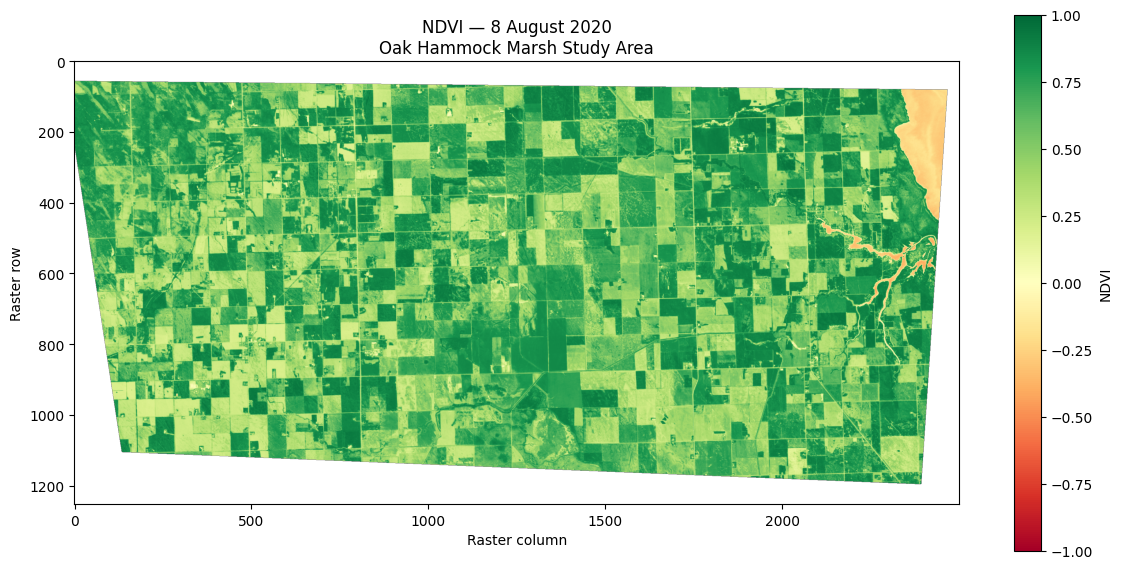

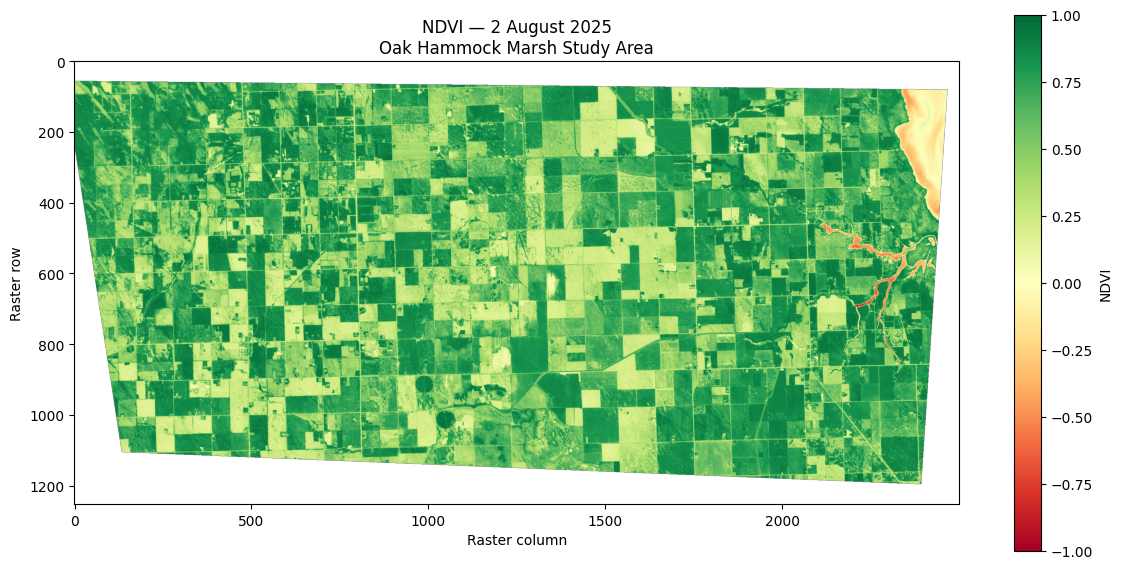

In [25]:
def save_ndvi_figure(ndvi, title, output_path):
    """Create and save an NDVI visualization."""

    fig, ax = plt.subplots(figsize=(12, 7))

    image = ax.imshow(
        ndvi,
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
    )

    ax.set_title(title)
    ax.set_xlabel("Raster column")
    ax.set_ylabel("Raster row")

    colorbar = fig.colorbar(
        image,
        ax=ax,
        shrink=0.8,
    )
    colorbar.set_label("NDVI")

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


save_ndvi_figure(
    ndvi_2020_common,
    "NDVI — 8 August 2020\nOak Hammock Marsh Study Area",
    figures_directory / "ndvi_2020.png",
)

save_ndvi_figure(
    ndvi_2025_common,
    "NDVI — 2 August 2025\nOak Hammock Marsh Study Area",
    figures_directory / "ndvi_2025.png",
)